In [26]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier,GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("NEISS_2024.csv")

In [3]:
df['Treatment_Date'].dtype

dtype('O')

In [4]:
df['Date_dt'] = pd.to_datetime(df['Treatment_Date'])

<Axes: xlabel='Date_dt'>

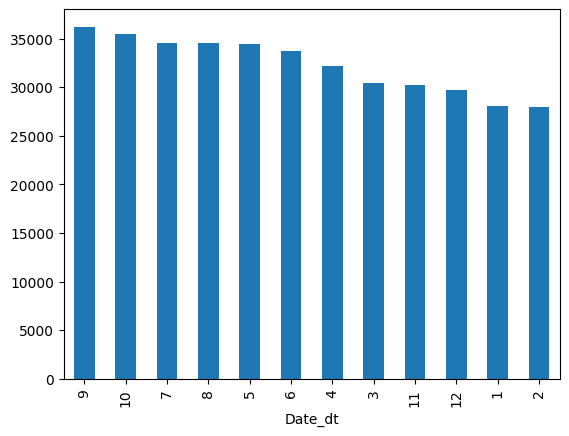

In [5]:
df['Date_dt'].dt.month.value_counts().plot(kind="bar")

In [6]:
# df["Product_1"].unique()

In [7]:
df[['Product_1', 'Product_2', 'Product_3']]=df[['Product_1', 'Product_2', 'Product_3']].fillna(9999)

In [8]:
df['products'] = df[['Product_1', 'Product_2', 'Product_3']].apply(lambda x: set(x), axis=1)

In [9]:
df['products'] = df['products'].apply(lambda x: set(int(i) for i in x if pd.notna(i)))
 

In [11]:
bikes = df[df['products'].apply(lambda x: 5040 in x)].copy()

In [22]:
season = bikes['Date_dt'].dt.month.value_counts()
season_df = season.to_frame()
season_df.reset_index(inplace=True)
season_df.sort_values(by="Date_dt",ascending=False, inplace=True)

In [34]:
bikes["mon"] = bikes['Date_dt'].dt.month

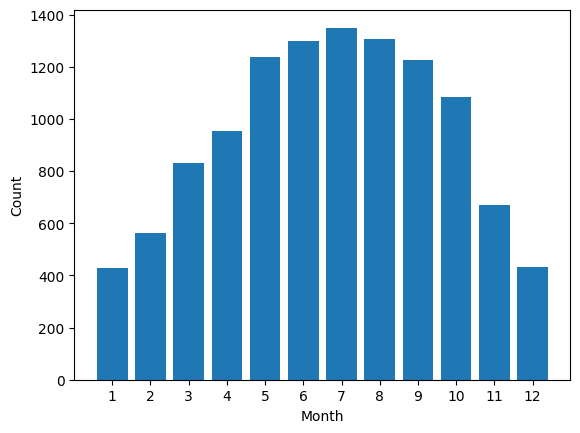

In [30]:
plt.bar(season_df['Date_dt'], season_df["count"])
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(range(1,13));

In [43]:
ds = bikes.groupby('Disposition').agg(disp_sum = ('Weight', 'sum'))
total = ds["disp_sum"].sum()
ds["Percent"] = round((ds["disp_sum"]/ total)*100,2)

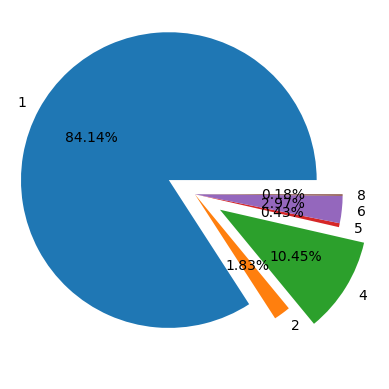

In [49]:
# ds.count()
plt.pie(ds["Percent"],labels=ds.index, explode=[0.2,0,0.2,0,0,0], autopct="%.2f%%");

<Axes: xlabel='mon'>

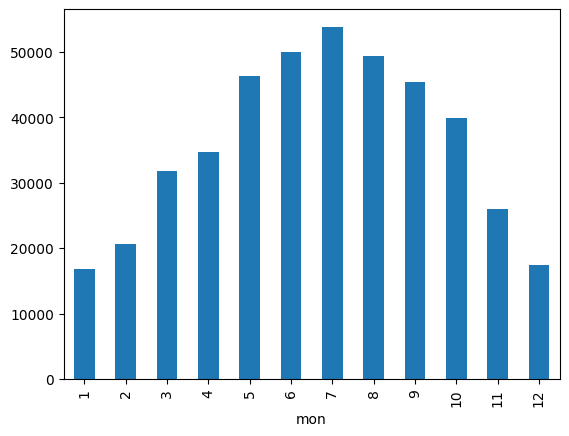

In [35]:
bikes.groupby(bikes['mon'])['Weight'].sum().plot(kind='bar')

In [62]:
bikes['Age_clean'] = bikes['Age'].apply(lambda x : int((x-200)/12) if x>200 else int(x))

<Axes: xlabel='Age_clean'>

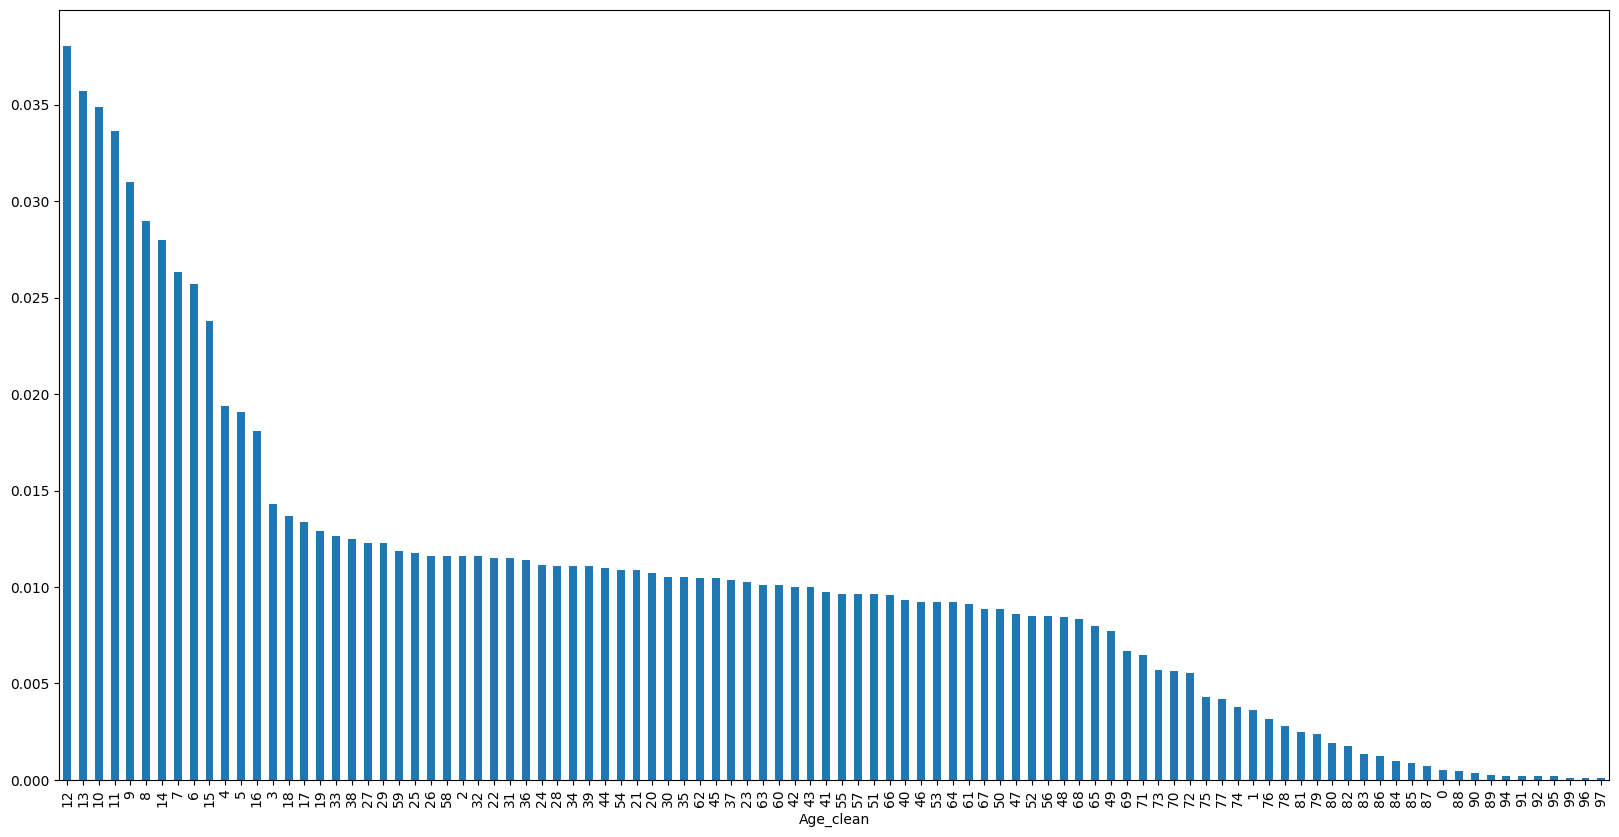

In [63]:
plt.figure(figsize=(20,10))
bikes['Age_clean'].value_counts(True).plot(kind="bar")

In [70]:
import nltk.tokenize as tk

In [ ]:
tk.word_tokenize

In [72]:
tk.word_tokenize("Hello hi")

LookupError: 
**********************************************************************
  Resource [93mpunkt[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt/PY3/english.pickle[0m

  Searched in:
    - '/Users/art/nltk_data'
    - '/Users/art/anaconda3/nltk_data'
    - '/Users/art/anaconda3/share/nltk_data'
    - '/Users/art/anaconda3/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
    - ''
**********************************************************************


In [71]:
bikes["Narrative"].apply(lambda x : tk.word_tokenize(x))

LookupError: 
**********************************************************************
  Resource [93mpunkt[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt/PY3/english.pickle[0m

  Searched in:
    - '/Users/art/nltk_data'
    - '/Users/art/anaconda3/nltk_data'
    - '/Users/art/anaconda3/share/nltk_data'
    - '/Users/art/anaconda3/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
    - ''
**********************************************************************


In [74]:
pip install pickle

ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle
Note: you may need to restart the kernel to use updated packages.


In [75]:
s1 = "On a $50,000 mortgage of 30 years at 8 percent, the monthly payment would be $366.88."
tk.word_tokenize(s1)

LookupError: 
**********************************************************************
  Resource [93mpunkt[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt/PY3/english.pickle[0m

  Searched in:
    - '/Users/art/nltk_data'
    - '/Users/art/anaconda3/nltk_data'
    - '/Users/art/anaconda3/share/nltk_data'
    - '/Users/art/anaconda3/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
    - ''
**********************************************************************
